# EDA — zbiór do wykrywania języka

Krótka analiza pliku CSV: zawartość kolumn, rozkład klas, długości tekstów.

Uruchom z katalogu projektu po `pip install -e ".[dev]"` (lub zainstaluj `jupyter`, `matplotlib` ręcznie).

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# Ścieżka względem tego notatnika (notebooks/ -> ../data/)
DATA_PATH = Path("../data/language_detection.csv").resolve()
print(f"Plik danych: {DATA_PATH}")
print(f"Istnieje: {DATA_PATH.is_file()}")

## Wczytanie i pierwszy rzut oka

In [2]:
df = pd.read_csv(DATA_PATH)
print("Wymiar (wiersze, kolumny):", df.shape)
print("\nKolumny:", list(df.columns))
print("\nTypy:")
print(df.dtypes)
df.head(8)

Wymiar (wiersze, kolumny): (10337, 2)

Kolumny: ['Text', 'Language']

Typy:
Text        object
Language    object
dtype: object


,Text,Language
0,"Nature, in the broadest sense, is the natural...",English
1,"""Nature"" can refer to the phenomena of the phy...",English
2,"The study of nature is a large, if not the onl...",English
3,"Although humans are part of nature, human acti...",English
4,[1] The word nature is borrowed from the Old F...,English
5,"[2] In ancient philosophy, natura is mostly us...",English
6,"[3][4] \nThe concept of nature as a whole, the...",English
7,During the advent of modern scientific method ...,English


## Braki i duplikaty

In [3]:
print("Braki (NaN) per kolumna:")
print(df.isna().sum())
print("\nPuste stringi w Text:", (df["Text"].astype(str).str.strip() == "").sum())
dups = df.duplicated().sum()
print(f"\nZduplikowane wiersze (całość): {dups}")
print(f"Unikalne teksty: {df['Text'].nunique()} / {len(df)}")

Braki (NaN) per kolumna:
Text        0
Language    0
dtype: int64

Puste stringi w Text: 0

Zduplikowane wiersze (całość): 66
Unikalne teksty: 10267 / 10337


## Rozkład języków (etykiety)

Liczba klas: 17

Top 15 języków:
Language
English       1385
French        1014
Spanish        819
Portugeese     739
Italian        698
Russian        692
Sweedish       676
Malayalam      594
Dutch          546
Arabic         536
Turkish        474
German         470
Tamil          469
Danish         428
Kannada        369
Name: count, dtype: int64


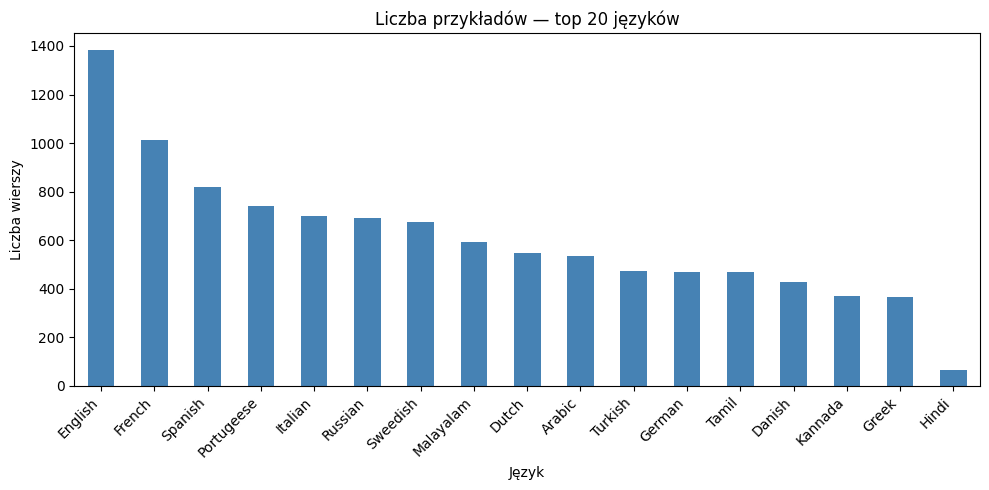

In [4]:
counts = df["Language"].value_counts()
print("Liczba klas:", counts.size)
print("\nTop 15 języków:")
print(counts.head(15))

fig, ax = plt.subplots(figsize=(10, 5))
counts.head(20).plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("Liczba przykładów — top 20 języków")
ax.set_xlabel("Język")
ax.set_ylabel("Liczba wierszy")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Długość tekstu (znaki)

count    10337.00
mean       124.06
std        253.69
min          1.00
25%         43.00
50%        100.00
75%        166.00
max      19088.00
Name: Text, dtype: float64


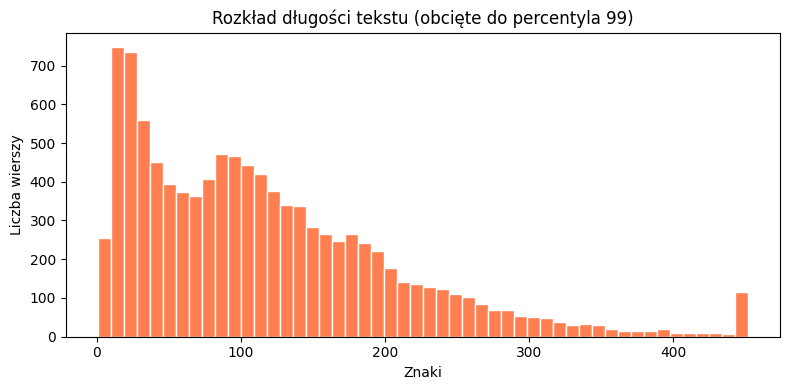

In [5]:
text_len = df["Text"].astype(str).str.len()
print(text_len.describe().round(2))

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(text_len.clip(upper=text_len.quantile(0.99)), bins=50, color="coral", edgecolor="white")
ax.set_title("Rozkład długości tekstu (obcięte do percentyla 99)")
ax.set_xlabel("Znaki")
ax.set_ylabel("Liczba wierszy")
plt.tight_layout()
plt.show()

## Przykładowe wiersze per język (losowo)

In [6]:
sample = df.groupby("Language", group_keys=False).sample(n=1, random_state=42).head(12)
for _, row in sample.iterrows():
    t = row["Text"][:200] + ("…" if len(str(row["Text"])) > 200 else "")
    print(f"[{row['Language']}] {t}\n")

[Arabic] [75] يمكن أن يؤدي هذا في بعض الأحيان إلى إزالة المعلومات التي، على الرغم من صحتها، لم يتم الحصول عليها بشكل صحيح.

[Danish] Ja selvfølgelig.

[Dutch] kan ik je daar even stoppen?

[English] This is especially true in the United States where there is a long-standing ethical dilemma of improving health care, but also increasing profits.

[French] vous pouvez le faire vous pouvez passer le toefl vous pouvez passer le gmat vous l'obtiendrez.

[German] das wäre wunderbar, wäre es nicht gut, egal ich denke mit der Zeit wird sie wachsen, um zu lernen, lass uns über etwas anderes reden.

[Greek] σε πειράζει αν χρησιμοποιώ το κινητό σου; θα ήταν εντάξει αν έπαιρνα αύριο; ναι, παρακαλώ σιγουρευτείτε, προχωρήστε.

[Hindi] मुझे विश्वास नहीं हो रहा है कि आप मुझे मुस्कुराने के लिए किसी को बताने के लिए मज़ाक कर रहे हैं और खुश रहने के लिए आप हमेशा कह सकते हैं कि खुश रहो। अगर आप चाहते हैं कि कोई व्यक्ति रोने की आवाज़ करे और …

[Italian] La discesa dei prezzi per l'hardware e lo sviluppo di GPU